In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [20]:
# Load dataset
df = pd.read_excel("Online Retail.xlsx")

# Display first 5 records
print(df.head())

# Dataset information
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       -----------

In [21]:
#recieving customers with missing IDs
df =df.dropna(subset=['CustomerID'])

In [22]:
#removing cancelled invoices 
df = df[-df['InvoiceNo'].astype(str).str.startswith('C')]

In [23]:
#removing invalid quantities and prices
df = df[df['Quantity']>0]
df = df[df['UnitPrice']>0]

In [24]:
#creating TotalAmount 
df['TotalAmount'] = df['Quantity']*df['UnitPrice']

In [25]:
print(df.shape)
print(df.head())

(397884, 9)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom        15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom        22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  


In [31]:
#creating customer level data
customer_data = df.groupby("CustomerID").agg(
    Total_Spend = ("TotalAmount","sum"),
    Total_Quantity = ("Quantity","sum"),
    Number_Of_Transactions = ("InvoiceNo","nunique"),
    Number_Of_Products = ("StockCode","nunique"),
    Average_Order_Value = ("TotalAmount","mean"),
    Country = ("Country","first")
).reset_index()

print(customer_data.head())

   CustomerID  Total_Spend  Total_Quantity  Number_Of_Transactions  \
0     12346.0     77183.60           74215                       1   
1     12347.0      4310.00            2458                       7   
2     12348.0      1797.24            2341                       4   
3     12349.0      1757.55             631                       1   
4     12350.0       334.40             197                       1   

   Number_Of_Products  Average_Order_Value         Country  
0                   1         77183.600000  United Kingdom  
1                 103            23.681319         Iceland  
2                  22            57.975484         Finland  
3                  73            24.076027           Italy  
4                  17            19.670588          Norway  


In [34]:
#Catagorizing the customers 
customer_data["segment"] = pd.qcut(
    customer_data["Total_Spend"],
    q=3,
    labels = ["Low value ","Medium value","High value"]
)
print(customer_data["segment"].value_counts())

segment
Low value       1446
Medium value    1446
High value      1446
Name: count, dtype: int64


In [37]:
features = [
    "Total_Quantity",
    "Number_Of_Transactions",
    "Number_Of_Products",
    "Average_Order_Value"]
X = customer_data[features]
y = customer_data["segment"]

In [39]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
)

In [40]:
id3_model = DecisionTreeClassifier(
    criterion = "entropy",
    random_state = 42 ,
    max_depth= 4)

id3_model.fit(X_train,y_train)
y_pred = id3_model.predict(X_test)

print("Prediction:")
print(y_pred[:20])

Prediction:
['Low value ' 'Low value ' 'Low value ' 'Low value ' 'Medium value'
 'Low value ' 'Low value ' 'High value' 'Low value ' 'Medium value'
 'Low value ' 'Medium value' 'High value' 'High value' 'High value'
 'High value' 'Low value ' 'Low value ' 'High value' 'Low value ']


In [41]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy :",accuracy)
print("Classification report :")
print(classification_report(y_test,y_pred))

Accuracy : 0.8467741935483871
Classification report :
              precision    recall  f1-score   support

  High value       0.93      0.87      0.90       289
  Low value        0.87      0.85      0.86       289
Medium value       0.75      0.82      0.78       290

    accuracy                           0.85       868
   macro avg       0.85      0.85      0.85       868
weighted avg       0.85      0.85      0.85       868



In [42]:
print("\n Confusion Matrix")
print(confusion_matrix(y_test,y_pred))


 Confusion Matrix
[[251   2  36]
 [  0 247  42]
 [ 19  34 237]]


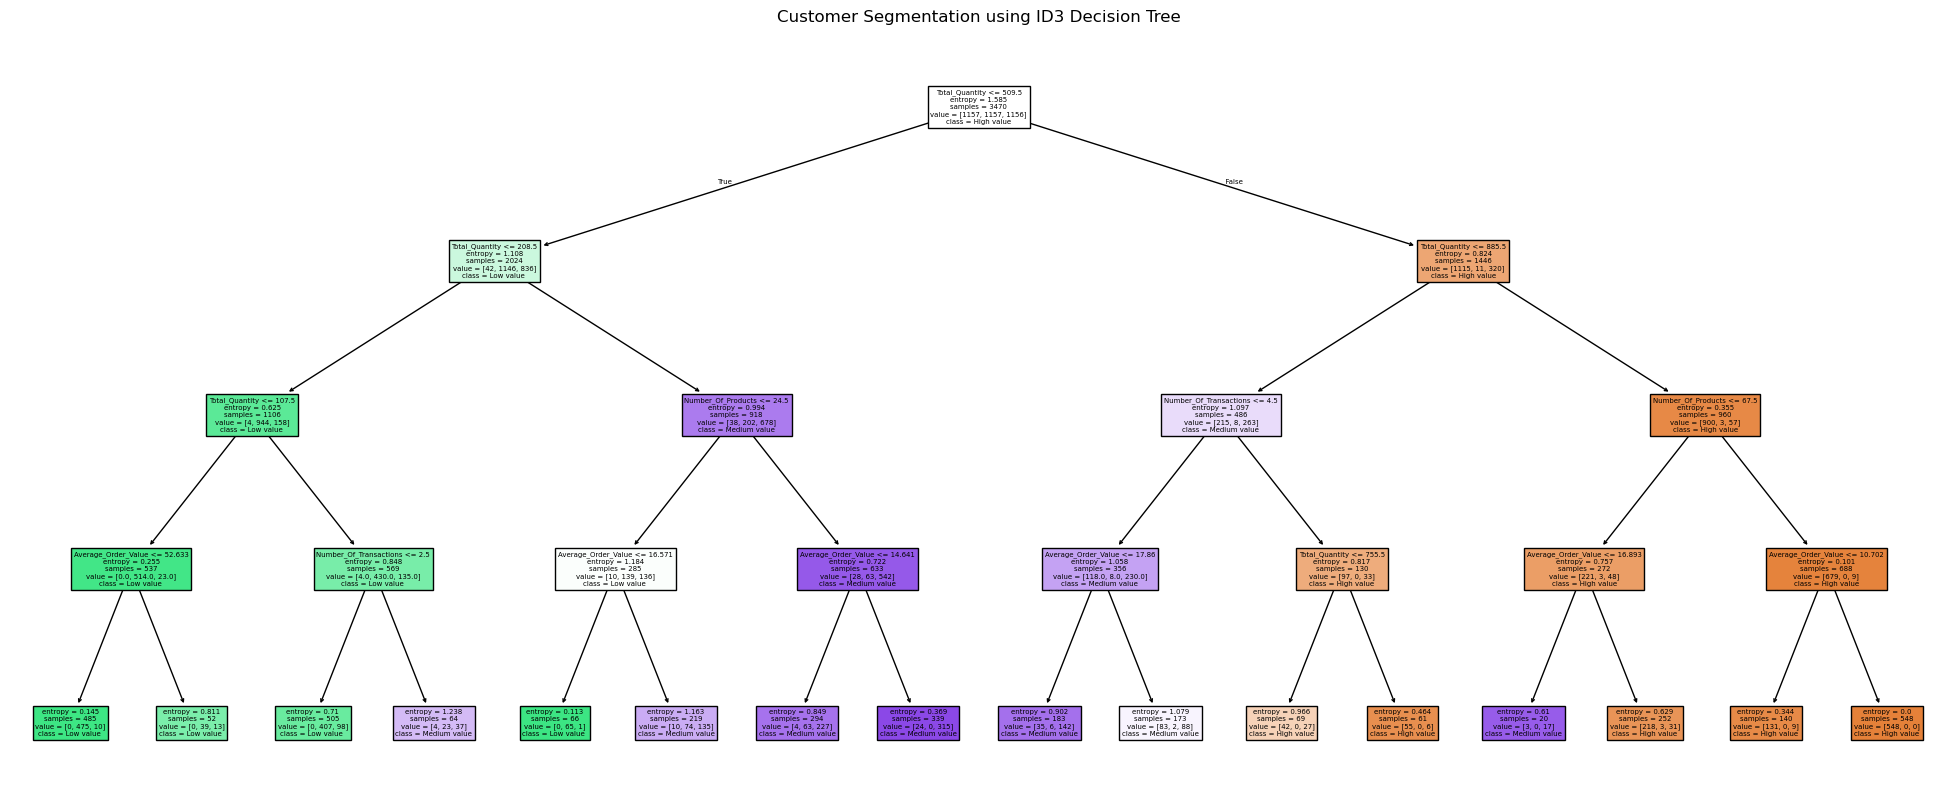

In [84]:
#Get import features from trained decision tree 
importance = pd.DataFrame({
    "Feature":features,
    "Importance":id3_model.feature_importances_})
#sort by importance
importance_sorted = importance.sort_values(
    "Importance",
    ascending = True)
#decisionTree
plt.figure(figsize=(25,10))
plot_tree(
    id3_model,
    feature_names = features,
    class_names = id3_model.classes_,
    filled = True,
    proportion = False
)
plt.title("Customer Segmentation using ID3 Decision Tree")
plt.show()

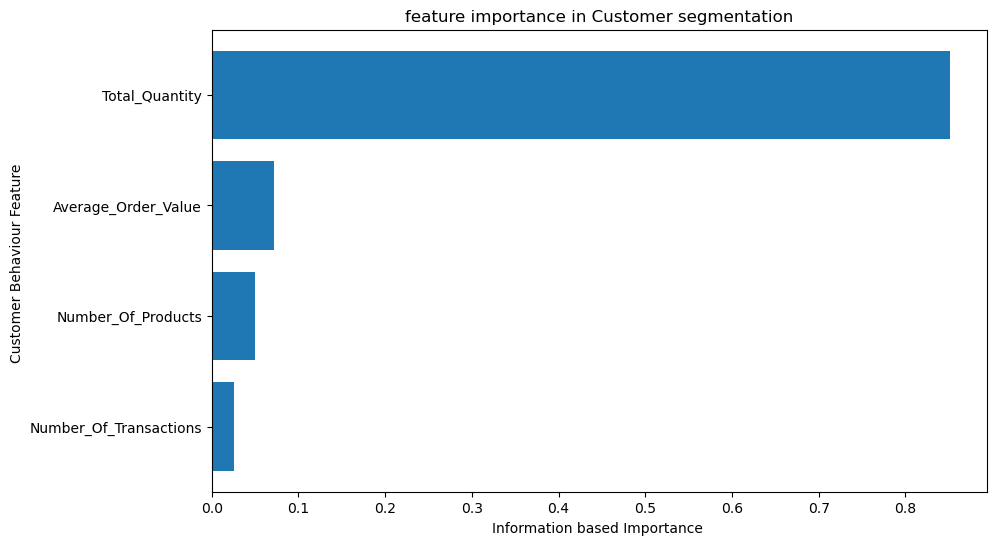

In [69]:
#feature importance
plt.figure(figsize = (10,6))
plt.barh(
    importance_sorted["Feature"],
    importance_sorted["Importance"]
)
plt.xlabel("Information based Importance ")
plt.ylabel("Customer Behaviour Feature ")
plt.title("feature importance in Customer segmentation")
plt.show()